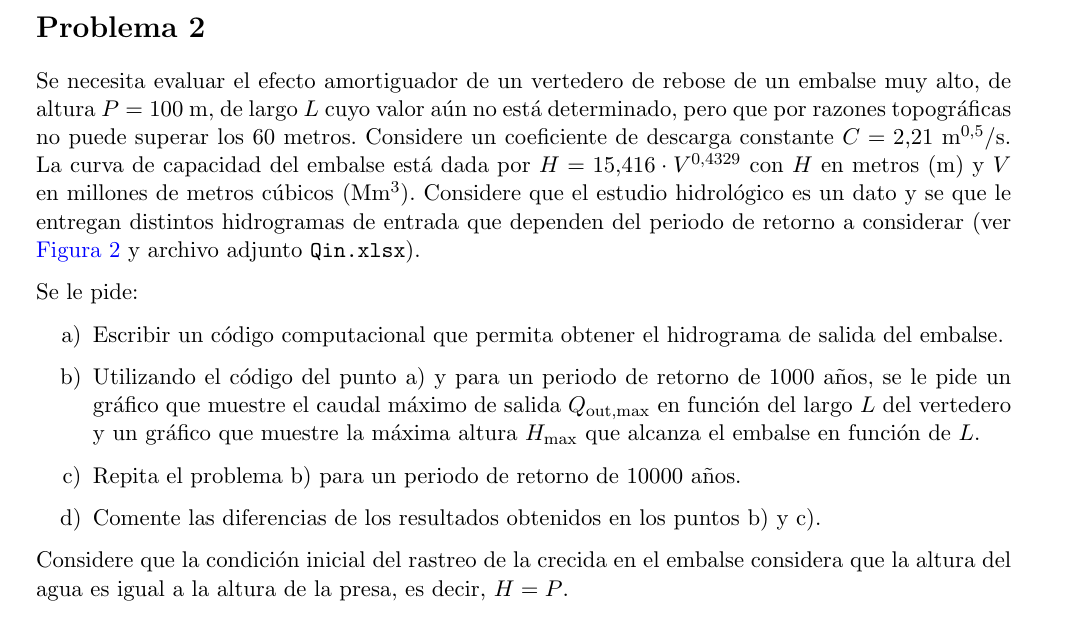
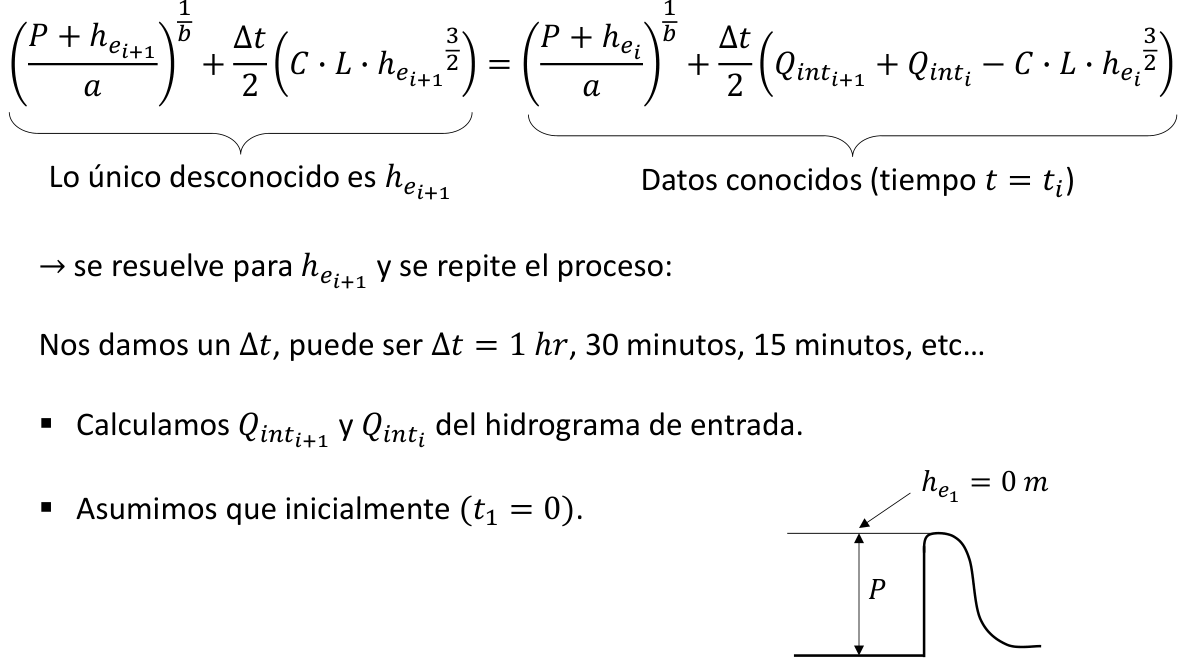

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#transformamos el archivo excel a csv
Q_in_df = pd.read_csv('Q_in.csv')
t_array = np.array(Q_in_df["Tiempo [hr]"])*3600

In [ ]:
P = 100 #[m]
#a y b de la ecuación de curva del embalse
a = 15.416 #[m]
b = 0.4329 #[m]
C = 2.21 #[m]
h_e_inicial = 0 #[m]
dt = 3600 #[s]
L_array = np.arange(1, 60 + 1, 1)

def derivada_centrada(f, x, i, delta_x):
  x_siguiente = np.array(x, dtype=float)
  x_atras = np.array(x, dtype=float)
  x_siguiente[i] += delta_x
  x_atras[i] -= delta_x
  f_siguiente = f(*x_siguiente)
  f_atras = f(*x_atras)
  return (f_siguiente - f_atras)/(2*delta_x)

def nr(funcion, h_e_actual, Q_in_actual, Q_in_siguiente, h_e_siguiente_estimacion, L, dt, delta_x=1e-5):
  tol=1e-4
  max_iter=50

  for i in range(max_iter):
    x_actual = np.array([h_e_siguiente_estimacion, h_e_actual, Q_in_actual, Q_in_siguiente, L, dt])
    f_val = funcion(*x_actual)
    df_val = derivada_centrada(funcion, x_actual, 0, delta_x)

    if abs(df_val) < 1e-10:
        df_val = 1e-10

    h_e_siguiente_estimacion_nuevo = h_e_siguiente_estimacion - (f_val / df_val)

    if abs(h_e_siguiente_estimacion_nuevo - h_e_siguiente_estimacion) < tol:
      return h_e_siguiente_estimacion_nuevo
    h_e_siguiente_estimacion = h_e_siguiente_estimacion_nuevo

  return h_e_siguiente_estimacion

def balance_embalse(h_e_siguiente, h_e_actual, Q_in_actual, Q_in_siguiente, L, dt):

  termino_volumen_siguiente = ((P + h_e_siguiente) / a)**(1.0 / b)
  termino_caudal_siguiente = (dt / 2.0) * (C * L * (h_e_siguiente**1.5))/1000000.0
  lado_izquierdo = termino_volumen_siguiente + termino_caudal_siguiente

  termino_volumen_actual = ((P + h_e_actual) / a)**(1.0 / b)
  Q_out_actual = C * L * (h_e_actual**1.5)
  termino_caudales_conocidos = (dt / 2.0) * (Q_in_siguiente + Q_in_actual - Q_out_actual)/ 1000000.0
  lado_derecho = termino_volumen_actual + termino_caudales_conocidos

  return lado_izquierdo - lado_derecho

def caudal_out(h_e_siguiente, L):
  return C * L * (h_e_siguiente**1.5)

def f_caudal_out_array(f, Q_array_entrada, L, dt):

  h_e_inicial = 0
  h_e_siguiente_estimacion = h_e_inicial + 1e-5
  Q_out = [caudal_out(h_e_inicial, L)]
  h_e_array = [h_e_inicial]

  for i in range(len(Q_array_entrada)-1):
    Q_in_actual = Q_array_entrada[i]
    Q_in_siguiente = Q_array_entrada[i + 1]
    h_e_siguiente = nr(f, h_e_inicial, Q_in_actual, Q_in_siguiente, h_e_siguiente_estimacion, L, dt)
    h_e_inicial = h_e_siguiente
    h_e_siguiente_estimacion = h_e_inicial + 1e-5
    Q_out.append(caudal_out(h_e_siguiente, L))
    h_e_array.append(h_e_siguiente)

  return np.array(Q_out), np.array(h_e_array)


In [ ]:
Q_in_df

,Tiempo [hr],10 años,20 años,50 años,100 años,200 años,500 años,1000 años,10000 años
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003679,0.480581
5,5,0.000000,0.000000,0.000000,0.015570,0.173364,0.612998,1.102859,4.223871
6,6,0.000000,0.000000,0.269227,0.821083,1.835647,3.852455,5.824327,15.457495
7,7,0.022024,0.448220,2.132290,4.376378,7.585893,13.170146,18.258565,39.528193
8,8,0.542190,2.455891,7.487422,13.143277,20.188173,31.300761,40.838747,77.210258
9,9,2.691915,7.915933,18.746225,29.361888,41.517285,59.453803,74.159956,127.307787


L (metros): 20
Periodo de retorno (años): 50


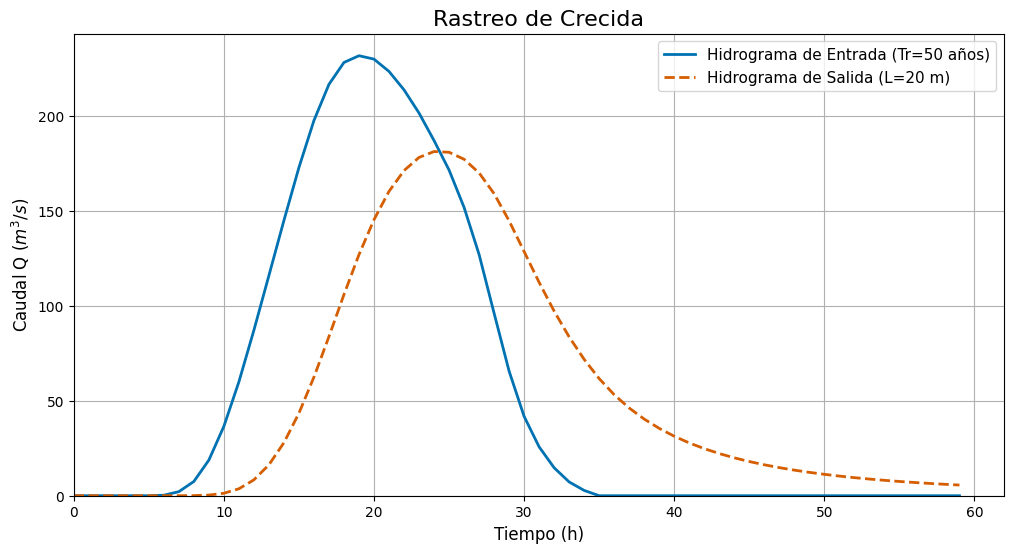

In [ ]:
#Parte a

L = int(input("L (metros): "))
periodo_retorno = int(input("Periodo de retorno (años): "))

q_in_array = np.array(Q_in_df[f"{periodo_retorno} años"])
q_out_array = f_caudal_out_array(balance_embalse, q_in_array, L, dt)[0]

plt.figure(figsize=(12, 6))

plt.plot(t_array/3600, q_in_array, label=f'Hidrograma de Entrada (Tr={periodo_retorno} años)', color='#0072B2', linewidth=2)
plt.plot(t_array/3600, q_out_array, label=f'Hidrograma de Salida (L={L} m)', color='#D55E00', linestyle='--', linewidth=2)

plt.title(f'Rastreo de Crecida', fontsize=16)
plt.xlabel('Tiempo (h)', fontsize=12)
plt.ylabel('Caudal Q ($m^3/s$)', fontsize=12)
plt.legend(fontsize=11)
plt.grid()
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.show()

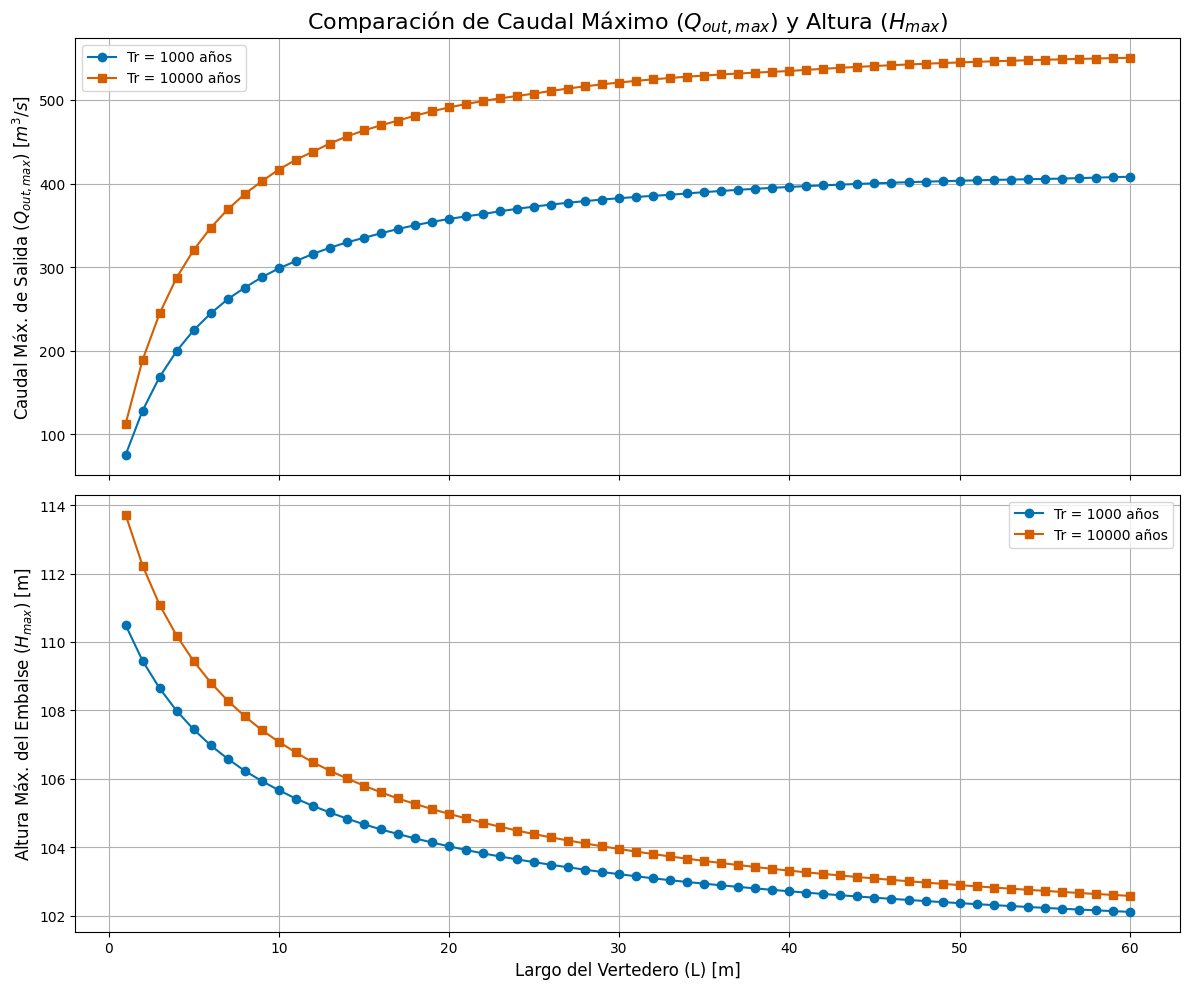

In [ ]:
#parte b y c
q_in_array_1000 = np.array(Q_in_df[f"{1000} años"])
q_in_array_10000 = np.array(Q_in_df[f"{10000} años"])

def f_largo_variable(f, Q_array_entrada, L_array, dt):
  Q_max_array = []
  h_e_array = []
  for L in L_array:
    q_out_L_array, h_e_L_array = f_caudal_out_array(f, Q_array_entrada, L, dt)
    Q_max_array.append(np.max(q_out_L_array))
    h_e_array.append(np.max(h_e_L_array) + P)

  return np.array(Q_max_array), np.array(h_e_array)

Q_max_array_1000, H_max_array_1000 = f_largo_variable(balance_embalse, q_in_array_1000, L_array, dt)
Q_max_array_10000, H_max_array_10000 = f_largo_variable(balance_embalse, q_in_array_10000, L_array, dt)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(L_array, Q_max_array_1000, 'o-', color='#0072B2', label='Tr = 1000 años')
ax1.plot(L_array, Q_max_array_10000, 's-', color='#D55E00', label='Tr = 10000 años')
ax1.set_title('Comparación de Caudal Máximo ($Q_{out,max}$) y Altura ($H_{max}$)', fontsize=16)
ax1.set_ylabel('Caudal Máx. de Salida ($Q_{out,max}$) [$m^3/s$]', fontsize=12)
ax1.legend()
ax1.grid(True)

ax2.plot(L_array, H_max_array_1000, 'o-', color='#0072B2', label='Tr = 1000 años')
ax2.plot(L_array, H_max_array_10000, 's-', color='#D55E00', label='Tr = 10000 años')
ax2.set_ylabel('Altura Máx. del Embalse ($H_{max}$) [m]', fontsize=12)
ax2.set_xlabel('Largo del Vertedero (L) [m]', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Parte D.

La diferencia más evidente es que a mayor Periodo de retorno, mayor será el caudal máximo como su altura máxima asociada, y eso se evidencia en el desplazamiento vertical de la curva del Tr de 10000 años.

Tambien se puede ver una relación inversa a medida que aumentamos el Largo del vertedero. Primero notamos que a menor L, existe una diferencia pequeña entre el caudal máximo para ambos periodos de retorno, por lo tanto ambos cumplen la misma eficiencia de regulación, sin embargo, para ese mismo L pequeño, se nota una diferencia importante entre los valores de H. Esto porque se debe cumplir la proporción entre Q y H de la ecuación de los vertederos. A medida que aumentamos el Largo vemos que la capacidad de regulación de ambos disminuye completamente y la diferencia de H entre estos tambien lo hace.

Además se puede apreciar que ambas curvas tienen características asintoticas a medida que aumentamos el Largo. Esto significa que aumentar el valor de L en rangos donde ya de por si es alto no entregará beneficios proporcionales a este aumento.